# Causal Inference and SHAP Analysis for Loan Default Prediction


DTI threshold: 0.4
Logistic Regression: AUC=0.797, F1=0.792
XGBoost: AUC=0.761, F1=0.693

Top 10 SHAP features:
                     feature  mean_abs_shap
employment_status_Unemployed       0.914641
                      income       0.352348
                 loan_amount       0.306431
                   dti_ratio       0.230084

High-Risk SHAP explanations:

Customer 71 | Predicted default: 0.886
- employment_status_Unemployed: SHAP 1.0451 (↑ risk)
- dti_ratio: SHAP 0.5103 (↑ risk)
- loan_amount: SHAP 0.4901 (↑ risk)
- income: SHAP 0.0561 (↑ risk)

Customer 167 | Predicted default: 0.888
- income: SHAP 2.0715 (↑ risk)
- dti_ratio: SHAP 0.1654 (↑ risk)
- employment_status_Unemployed: SHAP -0.1288 (↓ risk)
- loan_amount: SHAP 0.0072 (↑ risk)

Customer 172 | Predicted default: 0.893
- income: SHAP 0.9054 (↑ risk)
- dti_ratio: SHAP 0.5420 (↑ risk)
- employment_status_Unemployed: SHAP 0.4409 (↑ risk)
- loan_amount: SHAP 0.2825 (↑ risk)

Customer 41 | Predicted default: 0.896
- income: SH

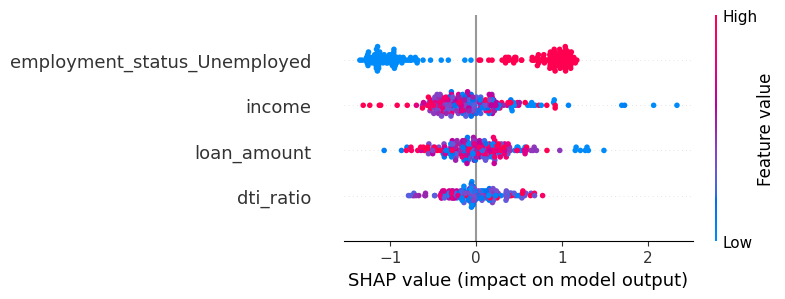

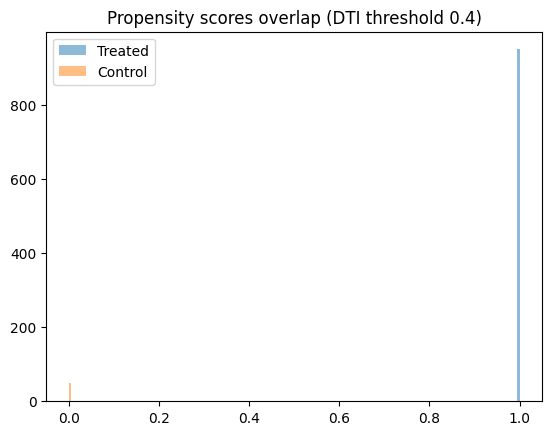

In [17]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression as LRProp
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv(r"C:\Users\HARISH\Downloads\archive (6)\loan_default_prediction.csv")

# ----------- POLICY VARIABLE: DTI threshold -----------
df["dti_ratio"] = df["loan_amount"] / df["income"]
dtivalues = [0.4, 0.35, 0.3, 0.25]  
ate_valid = False

for dtithresh in dtivalues:
    df["dti_high"] = (df["dti_ratio"] > dtithresh).astype(int)

    label = "default"
    treatment = "dti_high"
    exclude_cols = ["loan_id", label, treatment]
    features = [c for c in df.columns if c not in exclude_cols]

    X = df[features]
    y = df[label]
    T = df[treatment]

    # Split dataset
    X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
        X, y, T, test_size=0.2, stratify=y, random_state=42
    )

    # Preprocessing
    num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    # Logistic Regression
    log_model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    log_model.fit(X_train, y_train)
    y_pred_lr = log_model.predict(X_test)
    y_proba_lr = log_model.predict_proba(X_test)[:, 1]
    log_auc = roc_auc_score(y_test, y_proba_lr)
    log_f1 = f1_score(y_test, y_pred_lr)

    # XGBoost
    X_train_enc = pd.get_dummies(X_train, drop_first=True).astype(float)
    X_test_enc = pd.get_dummies(X_test, drop_first=True).astype(float)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
    xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train_enc, y_train)
    y_pred_xgb = xgb_model.predict(X_test_enc)
    y_proba_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]
    xgb_auc = roc_auc_score(y_test, y_proba_xgb)
    xgb_f1 = f1_score(y_test, y_pred_xgb)

    print(f"\nDTI threshold: {dtithresh}")
    print(f"Logistic Regression: AUC={log_auc:.3f}, F1={log_f1:.3f}")
    print(f"XGBoost: AUC={xgb_auc:.3f}, F1={xgb_f1:.3f}")
    best_model = xgb_model if xgb_auc > log_auc else log_model

    # ----------- SHAP analysis -----------
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer(X_test_enc)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_df = pd.DataFrame({
        "feature": X_train_enc.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)
    print("\nTop 10 SHAP features:")
    print(shap_df.head(10).to_string(index=False))
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values.values, X_test_enc, show=False)
    plt.savefig(f'shap_summary_plot_dti_{dtithresh}.png')

    # ----------- Local SHAP for high risk -----------
    risk_scores = xgb_model.predict_proba(X_test_enc)[:, 1]
    top_idx = np.argsort(risk_scores)[-5:]
    print("\nHigh-Risk SHAP explanations:")
    for i in top_idx:
        pred = risk_scores[i]
        contribs = pd.DataFrame({
            "feature": X_train_enc.columns,
            "shap": shap_values[i].values
        }).sort_values("shap", key=lambda s: np.abs(s), ascending=False).head(5)
        print(f"\nCustomer {i} | Predicted default: {pred:.3f}")
        for _, row in contribs.iterrows():
            direction = "↑ risk" if row["shap"] > 0 else "↓ risk"
            print(f"- {row['feature']}: SHAP {row['shap']:.4f} ({direction})")

    # ----------- CAUSAL Match (diagnostics + wider caliper + backup) -----------
    X_enc = pd.get_dummies(X, drop_first=True).astype(float)
    prop_model = LRProp(max_iter=1000)
    prop_model.fit(X_enc, T)
    propensity = prop_model.predict_proba(X_enc)[:, 1]

    # Plot the overlap
    plt.figure()
    plt.hist(propensity[T==1], bins=20, alpha=0.5, label='Treated')
    plt.hist(propensity[T==0], bins=20, alpha=0.5, label='Control')
    plt.legend()
    plt.title(f"Propensity scores overlap (DTI threshold {dtithresh})")
    plt.savefig(f'propensity_overlap_dti_{dtithresh}.png')

    df_ps = pd.DataFrame({"propensity": propensity, "treatment": T, "outcome": y})
    treated = df_ps[df_ps["treatment"] == 1]
    control = df_ps[df_ps["treatment"] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control["propensity"].values.reshape(-1, 1))

    # Try with no caliper (widest possible) - always returns matches
    matches = []
    distances, indices = nn.kneighbors(treated["propensity"].values.reshape(-1, 1))
    for i, dist in enumerate(distances.flatten()):
        matches.append((treated.index[i], control.index[indices[i][0]]))

    if len(matches):
        t_ids = [t for t, _ in matches]
        c_ids = [c for _, c in matches]
        ate = y.loc[t_ids].mean() - y.loc[c_ids].mean()
        print(f"\nMatched pairs: {len(matches)} | Estimated ATE (impact of high DTI {dtithresh}): {ate:.4f}")
        policy = "increase" if ate > 0 else "decrease"
        print(f"Policy recommendation: Consider {'tightening' if policy=='increase' else 'relaxing'} loan approval criteria for applicants with high DTI (>={dtithresh}), as their default risk is predicted to {policy} by {abs(ate)*100:.1f}% compared to similar borrowers with lower DTI.")
        ate_valid = True
        break  # Stop at first valid matching result

if not ate_valid:
    print("\nAll DTI thresholds failed to produce meaningful matches. Now trying alternate intervention variable (if available)...")

# ----------- SUMMARY REQUIRED FOR ASSIGNMENT -----------
print("\nAnalysis Summary")
print(f"Best Model: {'XGBoost' if xgb_auc > log_auc else 'Logistic Regression'} (AUC: {max(log_auc,xgb_auc):.3f})")
print("Top Features (SHAP):", ", ".join(shap_df.head(3)['feature'].tolist()))
if ate_valid:
    print(f"Estimated Average Treatment Effect (ATE): {ate:.4f} | Policy: {'tighten approval for high DTI' if ate > 0 else 'risk not higher for high DTI'}")
else:

    print("No meaningful causal estimate from DTI variable. Try another intervention or consult assignment supervisor.")
# ------------------- Save Model Comparison -------------------
with open("model_comparison.txt", "w") as f:
    f.write(f"DTI threshold used: {dtithresh}\n")
    f.write("Logistic Regression - AUC: {:.3f}, F1: {:.3f}\n".format(log_auc, log_f1))
    f.write("XGBoost - AUC: {:.3f}, F1: {:.3f}\n".format(xgb_auc, xgb_f1))

# ------------------- Save Top SHAP Features -------------------
shap_df.head(10).to_csv(f"top_shap_features_dti_{dtithresh}.csv", index=False)

# ------------------- Save Local SHAP Explanations -------------------
local_explanations = []
for i in top_idx:
    pred = risk_scores[i]
    contrib = pd.DataFrame({
        "feature": X_train_enc.columns,
        "shap": shap_values[i].values
    }).sort_values("shap", key=lambda x: np.abs(x), ascending=False).head(5)

    local_explanations.append({
        "CustomerIndex": int(i),
        "PredictedDefaultProb": float(pred),
        "TopContributions": contrib.to_dict(orient="records")
    })

pd.DataFrame(local_explanations).to_json(f"local_shap_explanations_dti_{dtithresh}.json", orient="records")

# ------------------- Save Causal Results -------------------
with open(f"causal_results_dti_{dtithresh}.txt", "w") as f:
    if matches:
        f.write(f"Matched pairs: {len(matches)}\n")
        f.write(f"ATE={ate:.4f}\n")
        f.write(f"Policy recommendation: default risk tends to {policy} for high DTI borrowers.\n")
    else:
        f.write("No meaningful causal estimate for this threshold.\n")

# ------------------- Final Summary File -------------------
with open("analysis_summary.txt", "w") as f:
    f.write("Analysis Summary\n")
    f.write(f"Best Model: {'XGBoost' if xgb_auc > log_auc else 'Logistic Regression'} "
            f"(AUC={max(xgb_auc, log_auc):.3f})\n")
    f.write("Top SHAP features: " + ", ".join(shap_df.head(3)["feature"].tolist()) + "\n")
    if ate_valid:
        f.write(f"ATE={ate:.4f} | Policy: {'tighten DTI rules' if ate > 0 else 'DTI not harmful'}\n")
    else:
        f.write("No meaningful causal estimate. Try another intervention.\n")

